In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

print("OSMnx:", ox.__version__)
print("GeoPandas:", gpd.__version__)

OSMnx: 2.1.1
GeoPandas: 1.2.0


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

DATA_RAW.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(DATA_RAW)

/Users/modjrin1/Library/CloudStorage/OneDrive-AaltoUniversity/paper 4 - mobility spain/heat-conditioned-accessibility
/Users/modjrin1/Library/CloudStorage/OneDrive-AaltoUniversity/paper 4 - mobility spain/heat-conditioned-accessibility/data/raw


In [3]:
PROJECT_ROOT = Path.cwd()

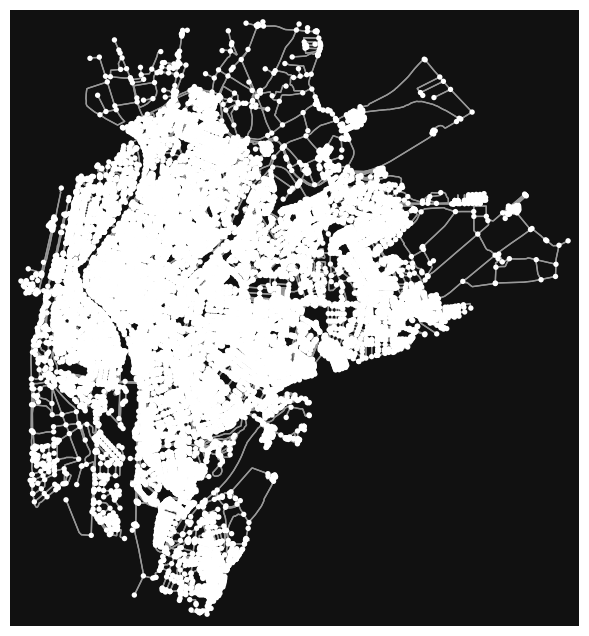

(<Figure size 800x800 with 1 Axes>,
 <Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>)

In [4]:
place = "Sevilla, Spain"

G = ox.graph_from_place(
    place,
    network_type="walk"
)

ox.plot_graph(G)

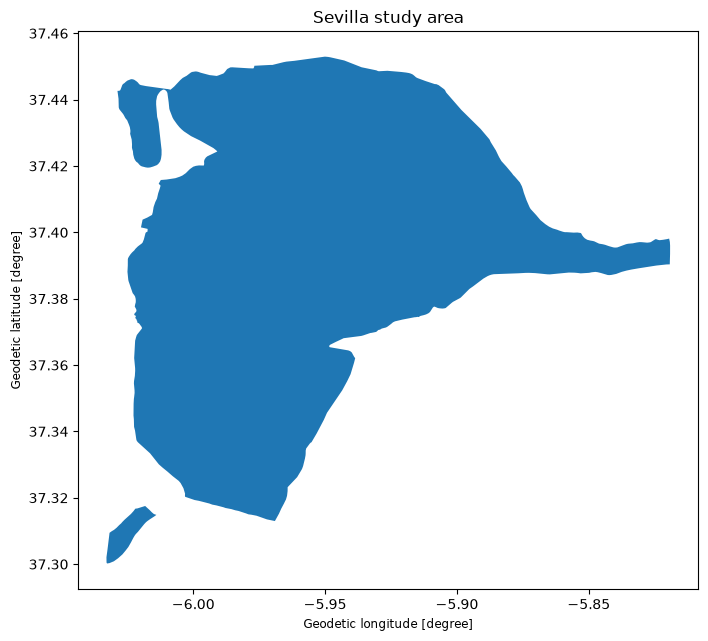

In [5]:
place = "Sevilla, Andalucía, Spain"
boundary = ox.geocode_to_gdf(place)
boundary

boundary.plot(figsize=(8, 8))
plt.title("Sevilla study area")
plt.show()

MultiDiGraph with 26320 nodes and 79920 edges


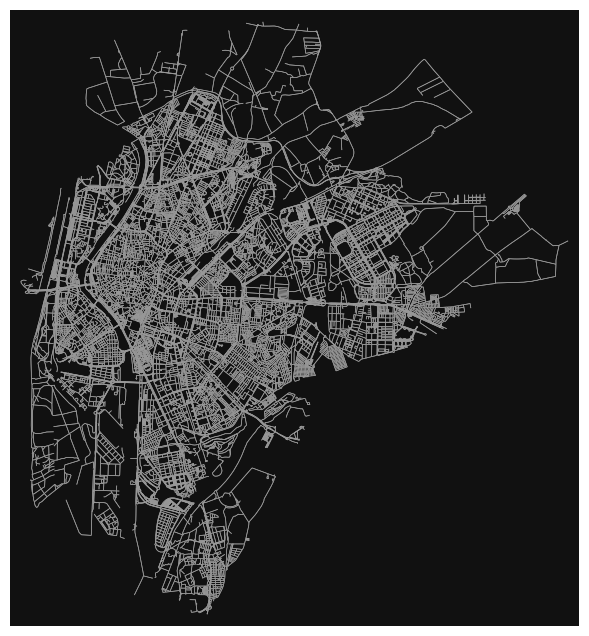

In [6]:
G = ox.graph_from_place(
    place,
    network_type="walk",
    simplify=True
)

print(G)
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.5
)

In [7]:
tags = {
    "building": True
}

buildings = ox.features_from_place(
    place,
    tags=tags
)

print(len(buildings))
buildings.head()
buildings = buildings[
    buildings.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()

29710


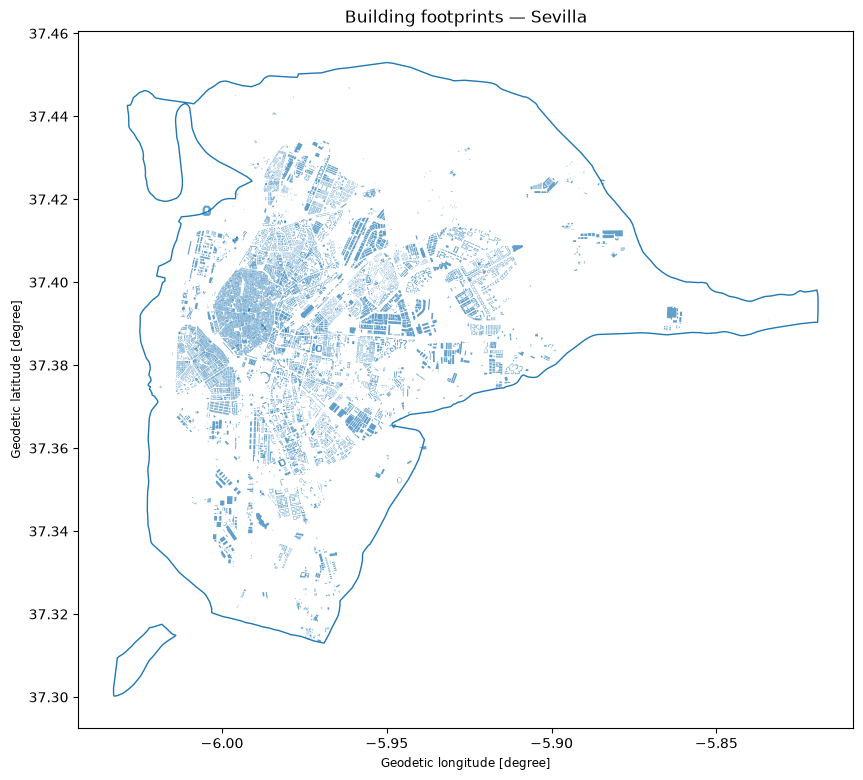

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

boundary.boundary.plot(
    ax=ax,
    linewidth=1
)

buildings.plot(
    ax=ax,
    linewidth=0,
    alpha=0.7
)

plt.title("Building footprints — Sevilla")
plt.show()

In [9]:
ox.save_graphml(
    G,
    filepath=DATA_RAW / "sevilla_walk.graphml"
)

In [10]:
boundary.to_file(
    DATA_RAW / "sevilla_boundary.gpkg",
    driver="GPKG"
)

buildings.to_file(
    DATA_RAW / "sevilla_buildings.gpkg",
    driver="GPKG"
)